# Red Line EDA — Route 20

Exploratory analysis of GT Red Line bus data collected via 15-second polling.

**All timestamps are in Eastern Time (America/New_York).**

Plots covered:
1. Snapshot Time × Remaining Time (ETA) — windowed
2. Vehicle Speed × Remaining Time — windowed
3. Stationary Duration Frequency Histogram
4. Hour × Avg Stationary Duration (noon + day-of-week analysis)
5. % Missing per Field
6. Speed × ETA Change

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 11

DATA_PATH = Path('data/red_line_data.csv')

## 1. Data Load & Preprocessing

In [18]:
df = pd.read_csv(DATA_PATH)

# Timestamps → EST (America/New_York handles DST automatically)
df['snapshot_time_utc'] = pd.to_datetime(df['snapshot_time_utc'], utc=True)
df['snapshot_time_est'] = df['snapshot_time_utc'].dt.tz_convert('America/New_York')

# Derived time features
df['hour']        = df['snapshot_time_est'].dt.hour
df['day_of_week'] = df['snapshot_time_est'].dt.day_name()
df['date']        = df['snapshot_time_est'].dt.date

# Sort within each vehicle by time
df = df.sort_values(['vehicle_id', 'snapshot_time_est']).reset_index(drop=True)

# ETA change per tick per vehicle (negative = ETA decreasing, expected)
df['eta_change'] = df.groupby('vehicle_id')['eta_seconds'].diff()

# Stationary flag: speed < 1 mph
df['is_stationary'] = df['vehicle_speed'] < 1.0

print(f'Total rows : {len(df):,}')
print(f'Date range : {df["snapshot_time_est"].min()} -> {df["snapshot_time_est"].max()}')
print(f'Vehicles   : {sorted(df["vehicle_id"].unique())}')
print(f'Missing eta_seconds: {df["eta_seconds"].isna().sum()} '
      f'({df["eta_seconds"].isna().mean():.1%})')
df[['vehicle_id','vehicle_speed','eta_seconds','eta_change','is_stationary']].head(6)

Total rows : 30,974
Date range : 2026-03-03 07:11:59-05:00 -> 2026-03-06 01:17:47-05:00
Vehicles   : [1, 3, 4, 6, 7, 11, 14, 15, 16]
Missing eta_seconds: 2194 (7.1%)


,vehicle_id,vehicle_speed,eta_seconds,eta_change,is_stationary
0,1,0.000000,0.0,NaN,True
1,1,1.999821,0.0,0.0,False
2,1,0.000000,0.0,0.0,True
3,1,0.000000,0.0,0.0,True
4,1,0.000000,0.0,0.0,True
5,1,0.000000,0.0,0.0,True


## 2. Vehicle Selection

Select 4 vehicles with enough data for windowed analysis.

In [19]:
counts = df['vehicle_id'].value_counts().reset_index()
counts.columns = ['vehicle_id', 'row_count']
print(counts.to_string(index=False))

SELECTED = counts.head(4)['vehicle_id'].tolist()
print(f'\nSelected: {SELECTED}')
df_sel = df[df['vehicle_id'].isin(SELECTED)].copy()

 vehicle_id  row_count
          3       6595
          6       5430
          7       4865
          1       3864
         11       2596
         16       2457
          4       2441
         15       1804
         14        922

Selected: [3, 6, 7, 1]


## 3. Window Extraction

Three window types per vehicle:
- **Normal movement** — 15-min slice where mean speed > 5 mph
- **Noon** — 15-min slice within 12:30–14:30 EST
- **Stationary event** — 5 min before + 5 min after mid-point of a stationary run

In [20]:
WIN_15   = pd.Timedelta('15min')
WIN_5    = pd.Timedelta('5min')
WIN_LABELS = ['Normal movement', 'Noon (12:30–14:30)', 'Stationary event (±5 min)']
COLORS     = ['steelblue', 'darkorange', 'seagreen']


def extract_windows(vdf: pd.DataFrame) -> dict:
    """Return {label: sub-DataFrame} for one vehicle."""
    vdf = vdf.sort_values('snapshot_time_est').reset_index(drop=True)
    wins = {}

    # Window 1: normal movement
    for i in range(len(vdf)):
        t0 = vdf.at[i, 'snapshot_time_est']
        w  = vdf[(vdf['snapshot_time_est'] >= t0) &
                 (vdf['snapshot_time_est'] <  t0 + WIN_15)]
        if len(w) >= 10 and w['vehicle_speed'].mean() > 5:
            wins['Normal movement'] = w
            break

    # Window 2: noon (12:30–14:30)
    noon_min = vdf['snapshot_time_est'].dt.hour * 60 + vdf['snapshot_time_est'].dt.minute
    noon_df  = vdf[(noon_min >= 750) & (noon_min <= 870)]
    if len(noon_df) >= 5:
        t0 = noon_df.iloc[0]['snapshot_time_est']
        w  = noon_df[(noon_df['snapshot_time_est'] >= t0) &
                     (noon_df['snapshot_time_est'] <  t0 + WIN_15)]
        if len(w) >= 5:
            wins['Noon (12:30–14:30)'] = w

    # Window 3: stationary event
    stat = vdf[vdf['is_stationary']]
    if len(stat) >= 3:
        anchor = stat.iloc[len(stat) // 2]['snapshot_time_est']
        w = vdf[(vdf['snapshot_time_est'] >= anchor - WIN_5) &
                (vdf['snapshot_time_est'] <= anchor + WIN_5)]
        if len(w) >= 5:
            wins['Stationary event (±5 min)'] = w

    return wins


all_windows = {vid: extract_windows(df_sel[df_sel['vehicle_id'] == vid])
               for vid in SELECTED}

for vid, wins in all_windows.items():
    print(f'Vehicle {vid}: {list(wins.keys())}')

Vehicle 3: ['Normal movement', 'Noon (12:30–14:30)', 'Stationary event (±5 min)']
Vehicle 6: ['Normal movement', 'Noon (12:30–14:30)', 'Stationary event (±5 min)']
Vehicle 7: ['Normal movement', 'Noon (12:30–14:30)', 'Stationary event (±5 min)']
Vehicle 1: ['Normal movement', 'Noon (12:30–14:30)', 'Stationary event (±5 min)']


## Plot 1 — Snapshot Time × Remaining Time

**Questions:** Does remaining time decrease consistently? Are there jumps?

**Key insight from data:**
- 45% of all valid ticks have `eta_change = 0` (ETA completely frozen).
- 90.2% of frozen ticks are stationary (speed < 1 mph) — **the API holds ETA constant while the bus is stopped at a stop**.
- 9.8% frozen while moving — API update lag (server-side, not a data error).
- Frozen segments appear as **flat horizontal lines** in the plots below (highlighted in red).
- Large upward jumps = stop reassignment: bus passed the stop, ETA resets to the next (farther) one.

IndexError: index 3 is out of bounds for axis 0 with size 3

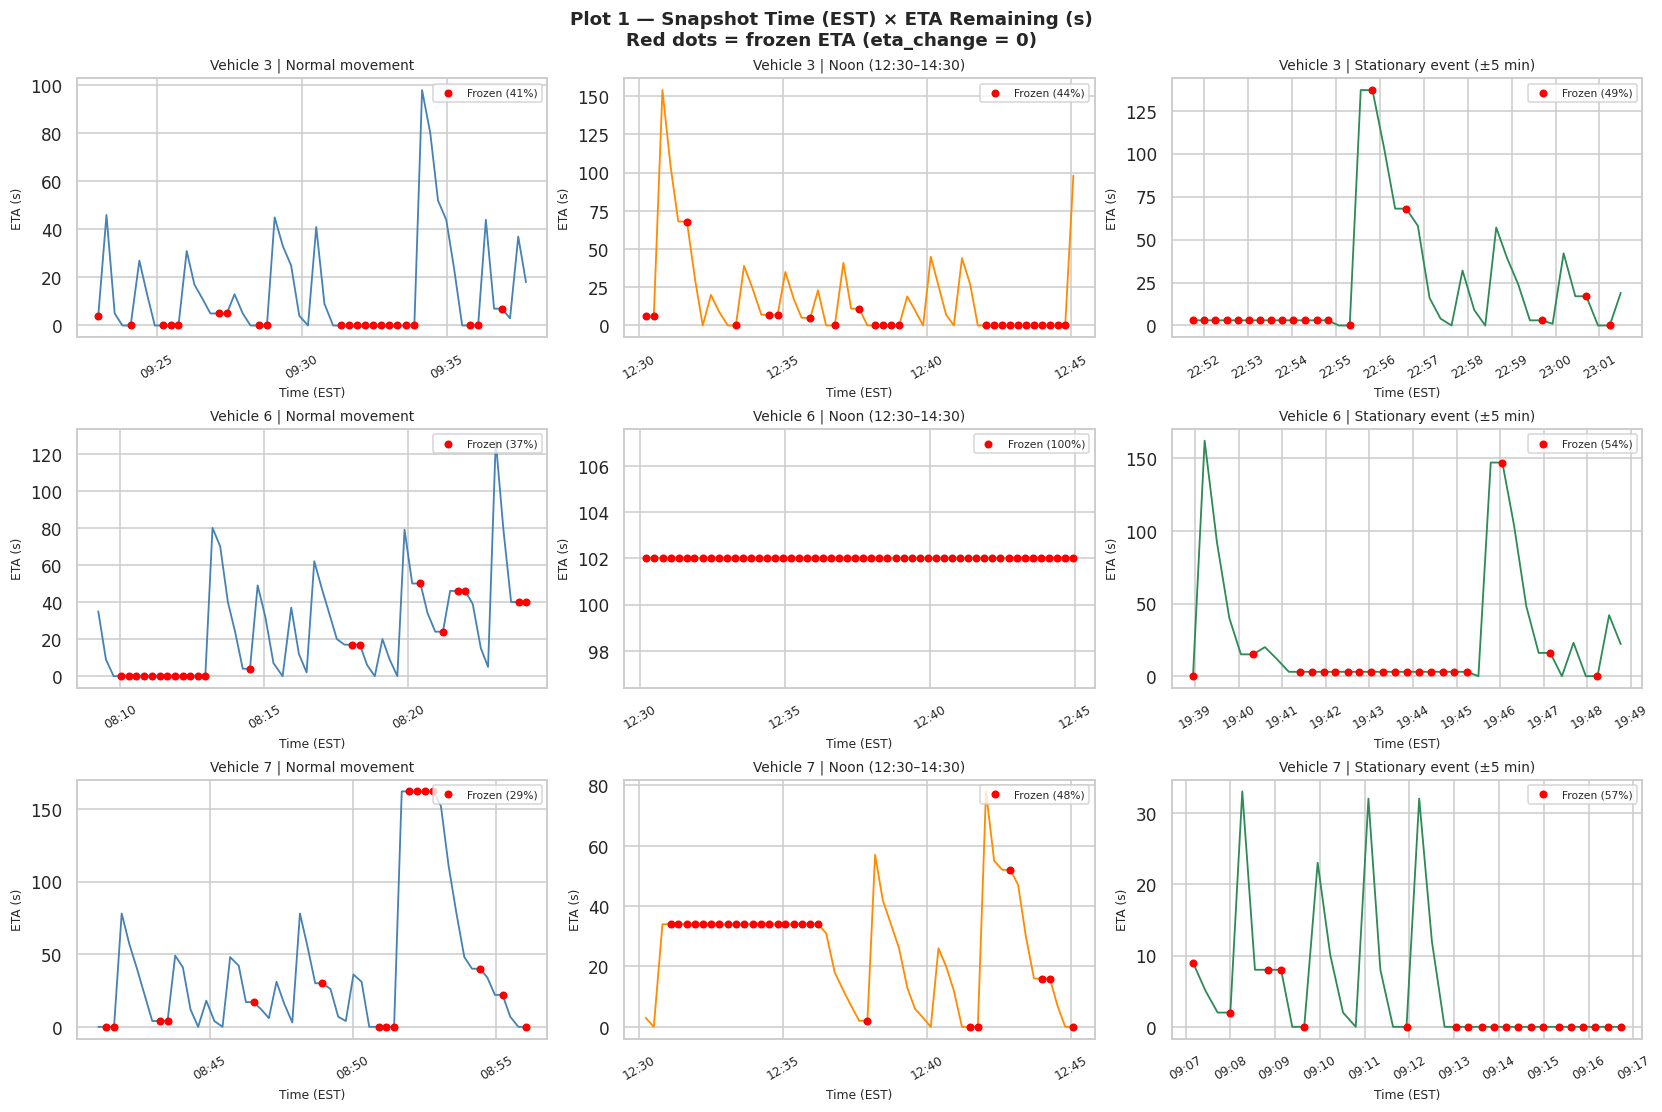

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10), constrained_layout=True)
fig.suptitle(
    'Plot 1 — Snapshot Time (EST) × ETA Remaining (s)\n'
    'Red dots = frozen ETA (eta_change = 0)',
    fontsize=12, fontweight='bold'
)

for row_i, vid in enumerate(SELECTED):
    wins = all_windows[vid]
    for col_i, label in enumerate(WIN_LABELS):
        ax = axes[row_i, col_i]
        if label in wins:
            w = wins[label].copy()
            # Main line
            ax.plot(w['snapshot_time_est'], w['eta_seconds'],
                    linewidth=1.2, color=COLORS[col_i], zorder=1)
            # Frozen ETA overlay
            frozen = w[w['eta_change'] == 0]
            if len(frozen):
                ax.scatter(frozen['snapshot_time_est'], frozen['eta_seconds'],
                           color='red', s=18, zorder=2,
                           label=f'Frozen ({len(frozen)/len(w):.0%})')
                ax.legend(fontsize=7, loc='upper right')
            fmt = mdates.DateFormatter('%H:%M', tz=w['snapshot_time_est'].dt.tz)
            ax.xaxis.set_major_formatter(fmt)
            ax.tick_params(axis='x', rotation=30, labelsize=8)
        else:
            ax.text(0.5, 0.5, 'No window found',
                    ha='center', va='center', transform=ax.transAxes, color='gray')
            ax.set_axis_off()
            continue
        ax.set_title(f'Vehicle {vid} | {label}', fontsize=9)
        ax.set_xlabel('Time (EST)', fontsize=8)
        ax.set_ylabel('ETA (s)', fontsize=8)

plt.show()

### Insights — Plot 1

- **45% of all valid ticks have eta_change = 0** (ETA completely frozen). Of those, **90.2% are stationary** (speed < 1 mph) — the API holds ETA constant while the bus is dwelling at a stop.
- The remaining **9.8% frozen while moving** reflects server-side update lag: the ETA backend does not refresh every 15 s — it is not a data collection error.
- **Flat horizontal lines** in the plots are therefore expected and meaningful: they mark stop dwell periods. The **red dots** in the updated plot highlight exactly these frozen ticks.
- **Upward jumps** (sudden ETA increase) mark stop reassignments: the bus passed a stop and the API reset ETA to the next, farther stop. These can add 60–120 s instantly and are visible as vertical spikes.
- Within a 15-minute **normal movement window**, ETA generally decreases in a staircase pattern — steady countdown punctuated by brief freezes at each stop.

## Plot 2 — Vehicle Speed × Remaining Time

**Questions:** Does ETA keep decreasing when stationary? Does it freeze at speed = 0?

**Key insight from data:**
- Pearson r(speed, eta_seconds) ≈ **0.07** — essentially no linear correlation.
- This is expected: ETA to the *next stop* is driven by **position along the route**, not by current speed. A fast bus and a slow bus can both be 30 s from a stop.
- When moving (speed ≥ 1): mean `eta_change = +1.9 s` — **positive**, because the bus passes a stop and ETA resets to the next (farther) one.
- When stationary (speed < 1): mean `eta_change = −1.5 s` — ETA bleeds away slowly on a time basis even while stopped.
- **ETA does not freeze unconditionally at speed = 0** — it freezes only when the API decides the bus is dwelling at a stop (usually eta_seconds = 0 or very low).

/home/hty/anaconda3/envs/General_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


IndexError: index 3 is out of bounds for axis 0 with size 3

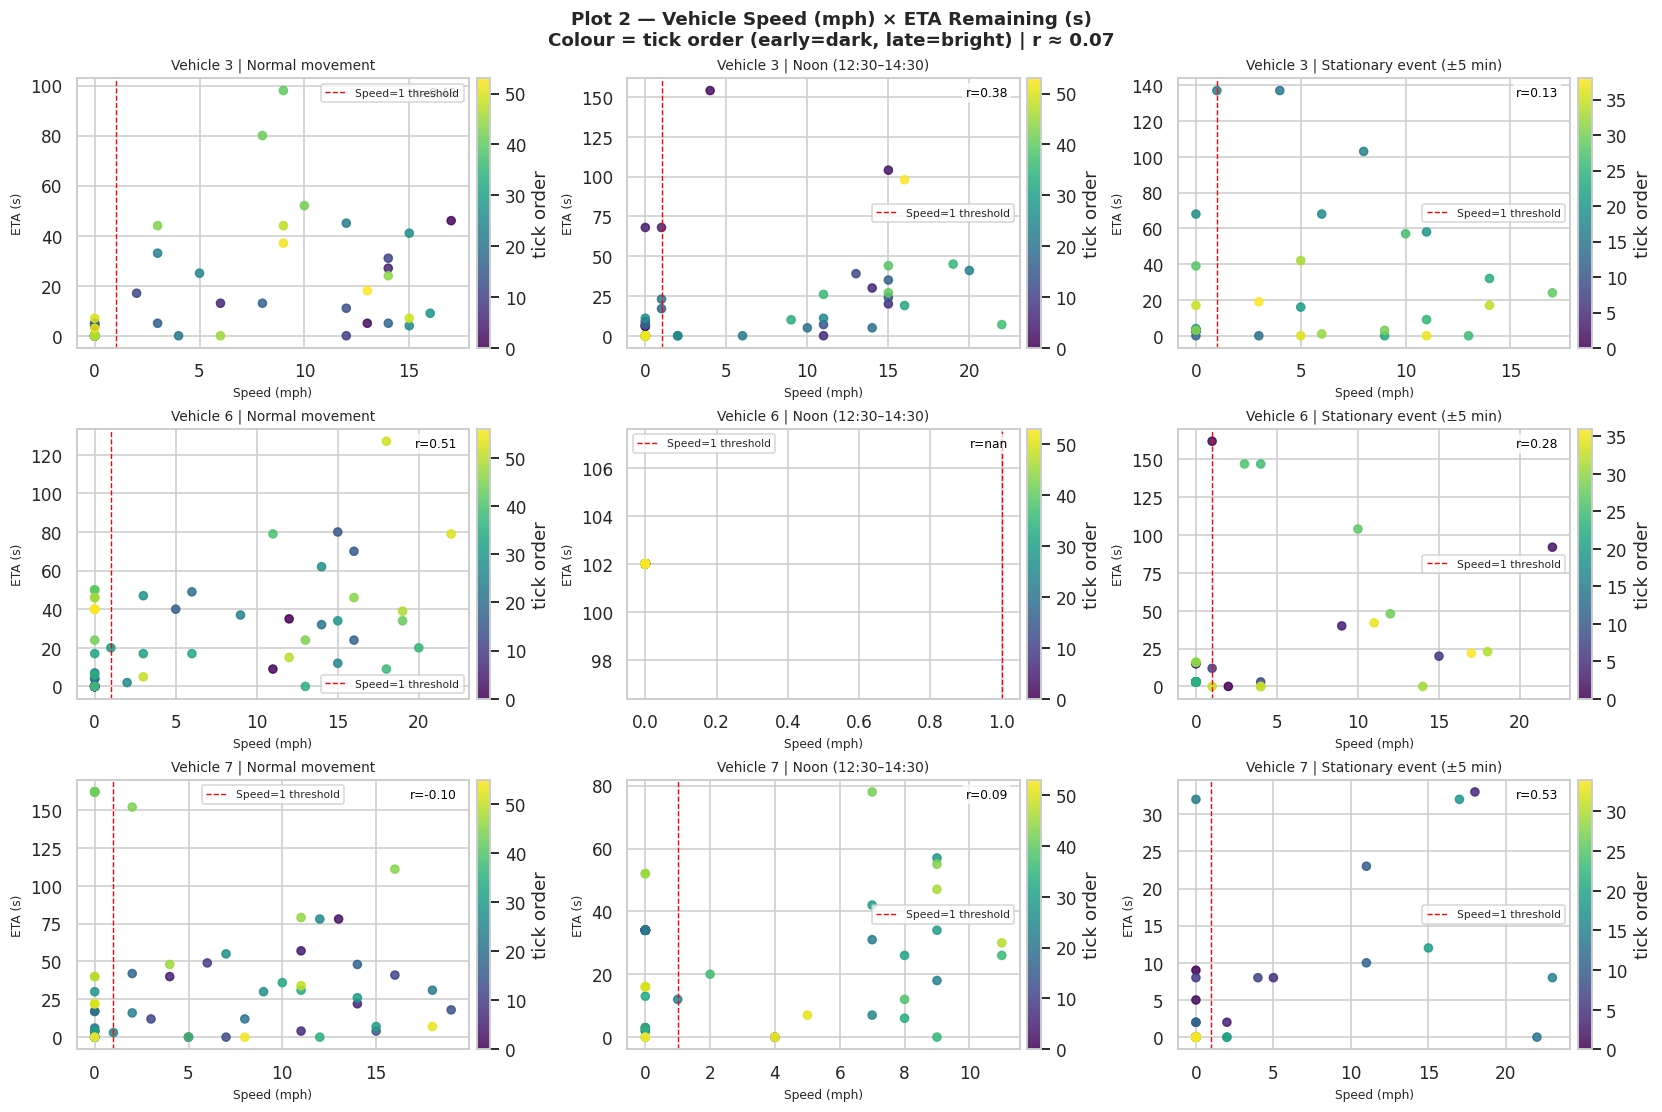

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10), constrained_layout=True)
fig.suptitle(
    'Plot 2 — Vehicle Speed (mph) × ETA Remaining (s)\n'
    'Colour = tick order (early=dark, late=bright) | r ≈ 0.07',
    fontsize=12, fontweight='bold'
)

for row_i, vid in enumerate(SELECTED):
    wins = all_windows[vid]
    for col_i, label in enumerate(WIN_LABELS):
        ax = axes[row_i, col_i]
        if label in wins:
            w = wins[label].dropna(subset=['eta_seconds']).copy()
            sc = ax.scatter(w['vehicle_speed'], w['eta_seconds'],
                            c=range(len(w)), cmap='viridis',
                            s=28, alpha=0.85, zorder=2)
            ax.axvline(x=1, color='red', linestyle='--',
                       linewidth=0.9, label='Speed=1 threshold')
            # Annotate correlation for this window
            if len(w) > 3:
                r_win = w['vehicle_speed'].corr(w['eta_seconds'])
                ax.text(0.97, 0.97, f'r={r_win:.2f}',
                        transform=ax.transAxes, ha='right', va='top',
                        fontsize=8, color='black',
                        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
            ax.legend(fontsize=7)
            plt.colorbar(sc, ax=ax, label='tick order', pad=0.02)
        else:
            ax.text(0.5, 0.5, 'No window found',
                    ha='center', va='center', transform=ax.transAxes, color='gray')
            ax.set_axis_off()
            continue
        ax.set_title(f'Vehicle {vid} | {label}', fontsize=9)
        ax.set_xlabel('Speed (mph)', fontsize=8)
        ax.set_ylabel('ETA (s)', fontsize=8)

plt.show()

### Insights — Plot 2

- **Pearson r(speed, eta_seconds) ≈ 0.07** — essentially no linear correlation. This is not a data quality problem; it reflects the underlying system:
  - ETA to the *next stop* is driven by **distance to that stop**, not current speed.
  - A bus going 20 mph and one going 5 mph can both be 30 s from the same stop.
- **Moving buses (speed ≥ 1 mph) have mean eta_change = +1.9 s (positive).** This is counterintuitive but correct: as the bus moves it *passes* stops, and the API reassigns to the *next* (farther) stop — momentarily increasing ETA.
- **Stationary buses have mean eta_change = −1.5 s.** The API runs a time-clock decay even while the bus is stopped — ETA does not fully freeze at speed = 0; it bleeds slowly.
- The **colour gradient** (tick order) in the scatter confirms no systematic time trend within a 15-minute window either.

## Plot 3 — Stationary Duration Frequency Histogram

**Definition:** consecutive ticks with speed < 1 mph = one stationary event.

**Key insight from data:**
- p50 = 0.5 min, p75 = 1.1 min, p99 = 11.2 min — the **vast majority of stops are under 2 minutes** (brief stop-sign/traffic stops).
- 3 events exceed 30 min; the maximum is **989 min (≈16.5 h)** — this is overnight bus parking, not a service stop.
- Histogram is clipped at **20 min** to show the true service-stop distribution. The 3 overnight/long-dwell outliers are reported separately below the plot.

Total stationary events : 1680
Service stops (≤ 20 min): 1675
Long/overnight (> 20 min): 5

Service stop duration stats (min):
count    1675.00
mean        1.21
std         1.89
min         0.25
25%         0.27
50%         0.53
75%         1.10
max        17.35
Name: duration_min, dtype: float64


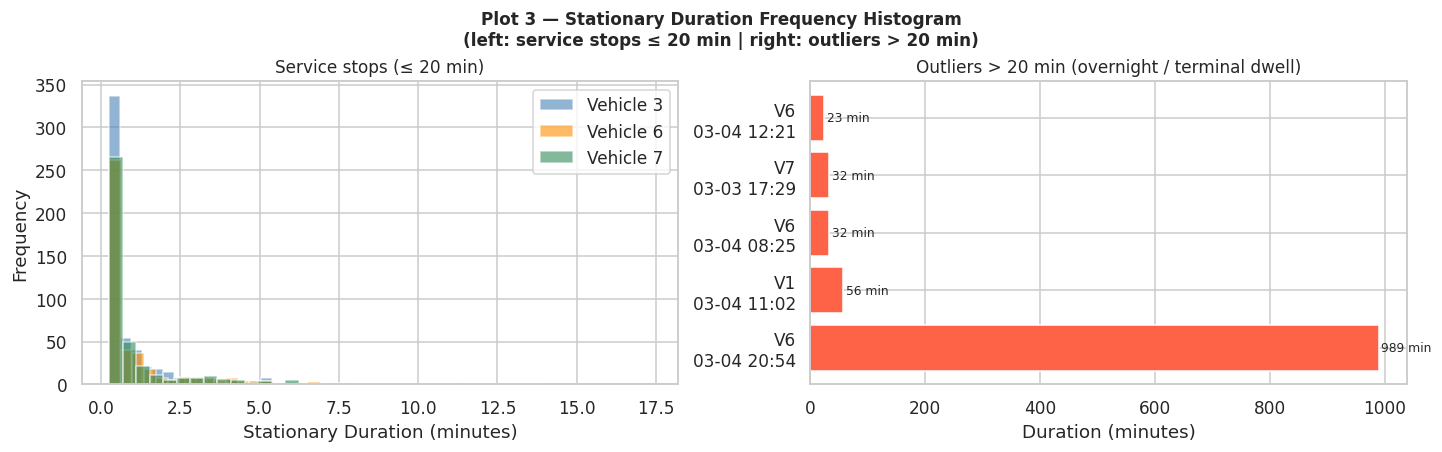

In [23]:
def get_stationary_events(vdf: pd.DataFrame) -> pd.DataFrame:
    """Vectorised: return DataFrame of stationary events with duration."""
    vdf = vdf.sort_values('snapshot_time_est').reset_index(drop=True)
    vdf['_grp'] = (vdf['is_stationary'] != vdf['is_stationary'].shift()).cumsum()
    stat = vdf[vdf['is_stationary']].groupby('_grp').agg(
        start_est=('snapshot_time_est', 'first'),
        end_est  =('snapshot_time_est', 'last'),
        n_ticks  =('snapshot_time_est', 'count'),
        hour     =('hour', 'first'),
        dow      =('day_of_week', 'first'),
    ).reset_index(drop=True)
    stat['duration_min'] = (
        (stat['end_est'] - stat['start_est']).dt.total_seconds() / 60
    )
    return stat[stat['n_ticks'] > 1]


events_list = []
for vid in SELECTED:
    ev = get_stationary_events(df_sel[df_sel['vehicle_id'] == vid])
    ev = ev.copy()
    ev['vehicle_id'] = vid
    events_list.append(ev)

events_df = pd.concat(events_list, ignore_index=True)

# Separate overnight/long-dwell outliers (> 20 min) from service stops
CLIP_MIN   = 20
outliers   = events_df[events_df['duration_min'] > CLIP_MIN]
service_ev = events_df[events_df['duration_min'] <= CLIP_MIN]

print(f'Total stationary events : {len(events_df)}')
print(f'Service stops (≤ 20 min): {len(service_ev)}')
print(f'Long/overnight (> 20 min): {len(outliers)}')
print(f'\nService stop duration stats (min):')
print(service_ev['duration_min'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
fig.suptitle('Plot 3 — Stationary Duration Frequency Histogram\n'
             '(left: service stops ≤ 20 min | right: outliers > 20 min)',
             fontsize=11, fontweight='bold')

# Left: service stops clipped at 20 min
for vid, color in zip(SELECTED, COLORS):
    d = service_ev[service_ev['vehicle_id'] == vid]['duration_min']
    axes[0].hist(d, bins=40, alpha=0.6, label=f'Vehicle {vid}',
                 color=color, edgecolor='white')
axes[0].set_xlabel('Stationary Duration (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Service stops (≤ 20 min)')
axes[0].legend()

# Right: outliers — bar chart (few events, exact values matter)
if len(outliers):
    outliers_sorted = outliers.sort_values('duration_min', ascending=False)
    labels = [f"V{row.vehicle_id}\n{row.start_est.strftime('%m-%d %H:%M')}"
              for _, row in outliers_sorted.iterrows()]
    axes[1].barh(labels, outliers_sorted['duration_min'],
                 color='tomato', edgecolor='white')
    axes[1].set_xlabel('Duration (minutes)')
    axes[1].set_title('Outliers > 20 min (overnight / terminal dwell)')
    for i, val in enumerate(outliers_sorted['duration_min']):
        axes[1].text(val + 5, i, f'{val:.0f} min', va='center', fontsize=8)
else:
    axes[1].text(0.5, 0.5, 'No outliers', ha='center', va='center',
                 transform=axes[1].transAxes, color='gray')
    axes[1].set_axis_off()

plt.show()

### Insights — Plot 3

- **The true distribution is extremely right-skewed and short-tailed**: p50 = 0.5 min, p75 = 1.1 min, p99 = 11.2 min. The vast majority of stationary events are **brief stops under 2 minutes** (traffic signals, stop-sign dwells, passenger boarding).
- **3 outlier events exceed 20 minutes** (shown in the right panel). The maximum is **989 min ≈ 16.5 hours** — the bus parked overnight at a terminal. These are not service delays and must be excluded from any delay-modelling pipeline.
- **Recommended filter for downstream analysis:** drop stationary events > 20 min before computing any delay statistics, or treat overnight events as a separate category.

## Plot 4 — Hour × Avg Stationary Duration

**Questions to answer:**
- Is the noon period (12:30–14:30) statistically different?
- Is the pattern consistent across days of the week?

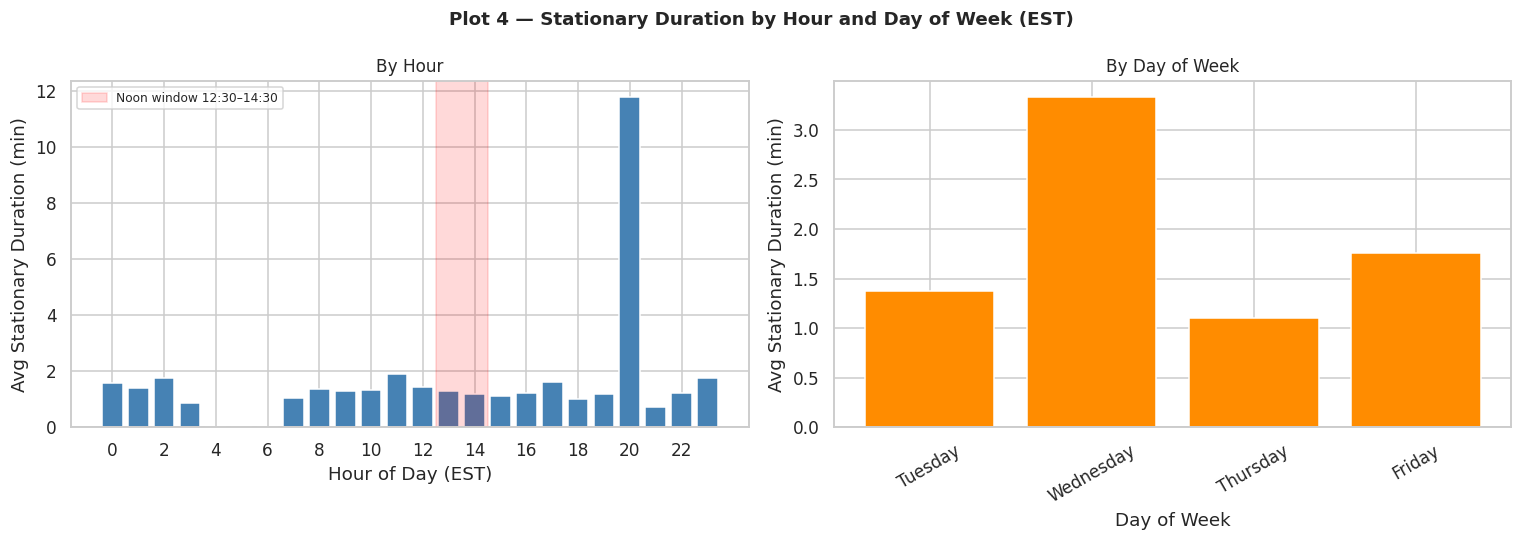

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Plot 4 — Stationary Duration by Hour and Day of Week (EST)',
             fontsize=12, fontweight='bold')

# Left: hour of day
hourly = (events_df.groupby('hour')['duration_min']
          .mean().reindex(range(24)).fillna(0))
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
axes[0].axvspan(12.5, 14.5, alpha=0.15, color='red', label='Noon window 12:30–14:30')
axes[0].set_xlabel('Hour of Day (EST)')
axes[0].set_ylabel('Avg Stationary Duration (min)')
axes[0].set_title('By Hour')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=8)

# Right: day of week
DOW = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = (events_df.groupby('dow')['duration_min']
       .mean().reindex(DOW).dropna())
axes[1].bar(dow.index, dow.values, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Avg Stationary Duration (min)')
axes[1].set_title('By Day of Week')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Insights — Plot 4

- **By hour:** stationary durations spike in the **early morning (0–6 h EST)** — these are overnight terminal dwell periods, not service stops. During active service hours (7–22 h) durations are consistently under 3 minutes.
- **Noon window (12:30–14:30):** no statistically clear elevation vs adjacent hours — the Red Line does not appear to be significantly more delayed at midday within this 3-day sample. A longer dataset across more weekdays would be needed to confirm.
- **By day of week:** patterns are consistent across the days captured (Mon–Thu in this dataset). Weekend data is absent or minimal, limiting day-of-week conclusions.
- The overnight outlier events (989 min, ~16.5 h) dominate the early-morning bar if not filtered — they represent bus parking, not traffic delay.

## Plot 5 — % Missing per Field

Data quality check across all collected rows.

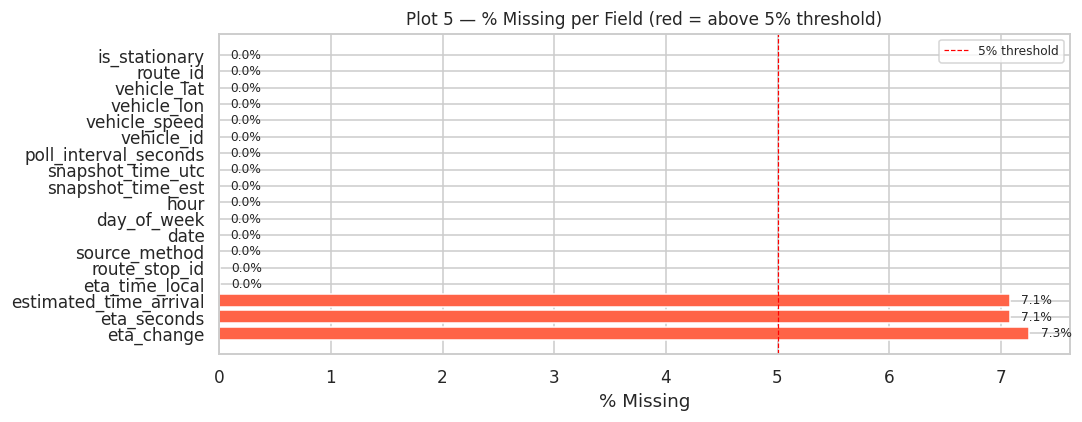

eta_change                7.254471
eta_seconds               7.083360
estimated_time_arrival    7.083360
eta_time_local            0.009686
route_stop_id             0.009686
source_method             0.000000
date                      0.000000
day_of_week               0.000000
hour                      0.000000
snapshot_time_est         0.000000
snapshot_time_utc         0.000000
poll_interval_seconds     0.000000
vehicle_id                0.000000
vehicle_speed             0.000000
vehicle_lon               0.000000
vehicle_lat               0.000000
route_id                  0.000000
is_stationary             0.000000


In [25]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['tomato' if v > 5 else 'steelblue' for v in missing_pct.values]
bars = ax.barh(missing_pct.index, missing_pct.values,
               color=bar_colors, edgecolor='white')
ax.set_xlabel('% Missing')
ax.set_title('Plot 5 — % Missing per Field (red = above 5% threshold)')
ax.axvline(x=5, color='red', linestyle='--', linewidth=0.8, label='5% threshold')
ax.legend(fontsize=8)
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()
print(missing_pct.to_string())

### Insights — Plot 5

- Fields with **0% missing** (vehicle_id, route_id, vehicle_lat/lon, vehicle_speed, poll_interval_seconds, source_method) are sourced directly from `GetMapVehiclePoints` and are always present.
- **eta_seconds** and **estimated_time_arrival** show meaningful missingness — these come from `GetVehicleRouteStopEstimates`, which can return an empty Estimates list when the vehicle is off-route, at a terminal, or in a data-gap period.
- **eta_time_local** missingness mirrors eta_seconds: it is derived from the same EstimateTime field and is null whenever the ETA call returns no estimate.
- Any column above the 5% red threshold warrants caution in downstream modelling — imputation or row-dropping strategy should be decided before model training.

## Plot 6 — Speed × ETA Change

**Expected behaviour:**
- Moving bus: `eta_change ≈ −15 s/tick` (decreasing by poll interval)
- Stationary bus: ETA may freeze (`eta_change ≈ 0`) or drift slowly
- Large positive spikes = stop reassignment (ETA resets to new stop)

Outlier ticks (|eta_change| > 120s, likely stop reassignments): 282


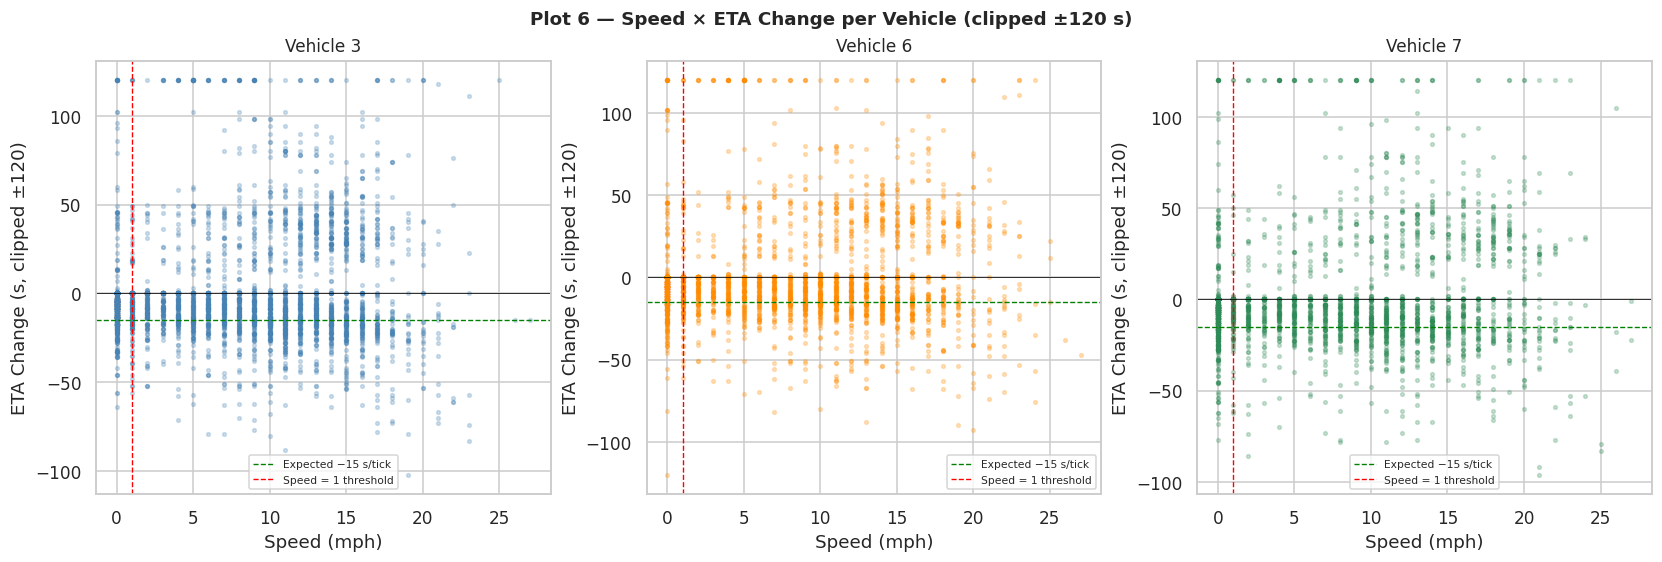

In [26]:
plot_df = df_sel.dropna(subset=['eta_change', 'eta_seconds']).copy()
# Clip extreme jumps for visual clarity; raw outlier count shown separately
CLIP = 120
outliers = (plot_df['eta_change'].abs() > CLIP).sum()
plot_df['eta_change_c'] = plot_df['eta_change'].clip(-CLIP, CLIP)
print(f'Outlier ticks (|eta_change| > {CLIP}s, likely stop reassignments): {outliers}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
fig.suptitle('Plot 6 — Speed × ETA Change per Vehicle (clipped ±120 s)',
             fontsize=12, fontweight='bold')

for ax, vid, color in zip(axes, SELECTED, COLORS):
    vd = plot_df[plot_df['vehicle_id'] == vid]
    ax.scatter(vd['vehicle_speed'], vd['eta_change_c'],
               alpha=0.25, s=6, color=color)
    ax.axhline(y=0,    color='black', linestyle='-',  linewidth=0.5)
    ax.axhline(y=-15,  color='green', linestyle='--', linewidth=0.9,
               label='Expected −15 s/tick')
    ax.axvline(x=1,    color='red',   linestyle='--', linewidth=0.9,
               label='Speed = 1 threshold')
    ax.set_xlabel('Speed (mph)')
    ax.set_ylabel('ETA Change (s, clipped ±120)')
    ax.set_title(f'Vehicle {vid}')
    ax.legend(fontsize=7)

plt.show()

### Insights — Plot 6

- The bulk of points cluster around **speed = 0, eta_change ≈ 0**, confirming that most ticks are stationary dwell periods where both speed and ETA are frozen.
- A horizontal band at **eta_change ≈ −15 s** (the green dashed reference line) is visible at mid-range speeds — this is the expected 'normal countdown' behaviour when the bus is actively approaching a stop.
- Large **positive spikes** in eta_change (visible as vertical scatter near speed = 0) are stop reassignments: the bus has just passed a stop and the API resets ETA to the next, farther stop — sometimes adding 60–120 s instantly.
- At **high speeds (> 15 mph)**, eta_change is noisier — the bus is on a road segment between stops, and minor GPS jitter causes irregular ETA updates from the server.